# Clusterização com Múltiplos Clusters
## Identificando Perfis de Clientes Bancários

No notebook anterior, separamos clientes em **dois grupos** com base em apenas duas variáveis. Na prática, porém:

- Geralmente temos **muitas variáveis** descrevendo cada cliente.
- **Não sabemos de antemão** quantos grupos existem.

Neste notebook, vamos:
1. Trabalhar com um dataset de clientes bancários com **5 características**.
2. Descobrir o **número ideal de clusters** usando o **Método do Cotovelo (Elbow)** e o **Coeficiente de Silhueta**.
3. **Interpretar** cada cluster para entender o perfil de cliente que ele representa.
4. Visualizar os clusters em um espaço de menor dimensão usando **PCA**.

## 1. Importação das Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples

sns.set_style('whitegrid')

## 2. Carregamento dos Dados

O dataset contém 300 clientes do banco com as seguintes variáveis:

- **idade**: idade do cliente em anos
- **renda_mensal**: renda mensal (R$)
- **saldo_poupanca**: saldo médio em poupança (R$)
- **num_transacoes_mes**: número de transações realizadas no mês
- **valor_medio_transacao**: valor médio de cada transação (R$)

In [2]:
df = pd.read_csv('dados_perfil_clientes.csv')
print(f'Dimensões: {df.shape[0]} linhas × {df.shape[1]} colunas')
df.head(10)

Dimensões: 300 linhas × 5 colunas


,idade,renda_mensal,saldo_poupanca,num_transacoes_mes,valor_medio_transacao
0,67,6708.08,93348.35,16,367.86
1,42,26240.67,53844.29,58,1139.85
2,41,9264.47,1718.80,60,342.75
3,24,4891.85,15285.77,7,180.47
4,64,6397.46,92274.77,13,542.40
5,67,5817.05,111232.70,22,435.26
6,70,5606.28,129295.49,27,684.10
7,36,8422.02,2497.69,116,309.72
8,23,3831.56,12471.79,20,125.74
9,68,5634.31,97489.79,7,249.15


In [3]:
df.describe().round(2)

,idade,renda_mensal,saldo_poupanca,num_transacoes_mes,valor_medio_transacao
count,300.00,300.00,300.00,300.00,300.00
mean,42.66,9579.51,47930.22,46.08,393.39
std,16.09,6949.59,49652.66,32.35,299.69
min,20.00,3222.86,0.00,3.00,61.60
25%,29.00,5061.66,4554.14,16.00,152.30
50%,39.00,6834.88,17343.94,34.00,309.14
75%,54.00,9135.33,92317.16,77.00,514.25
max,77.00,33297.73,181011.55,123.00,1431.06


## 3. Análise Exploratória

### 3.1 Distribuição das Variáveis

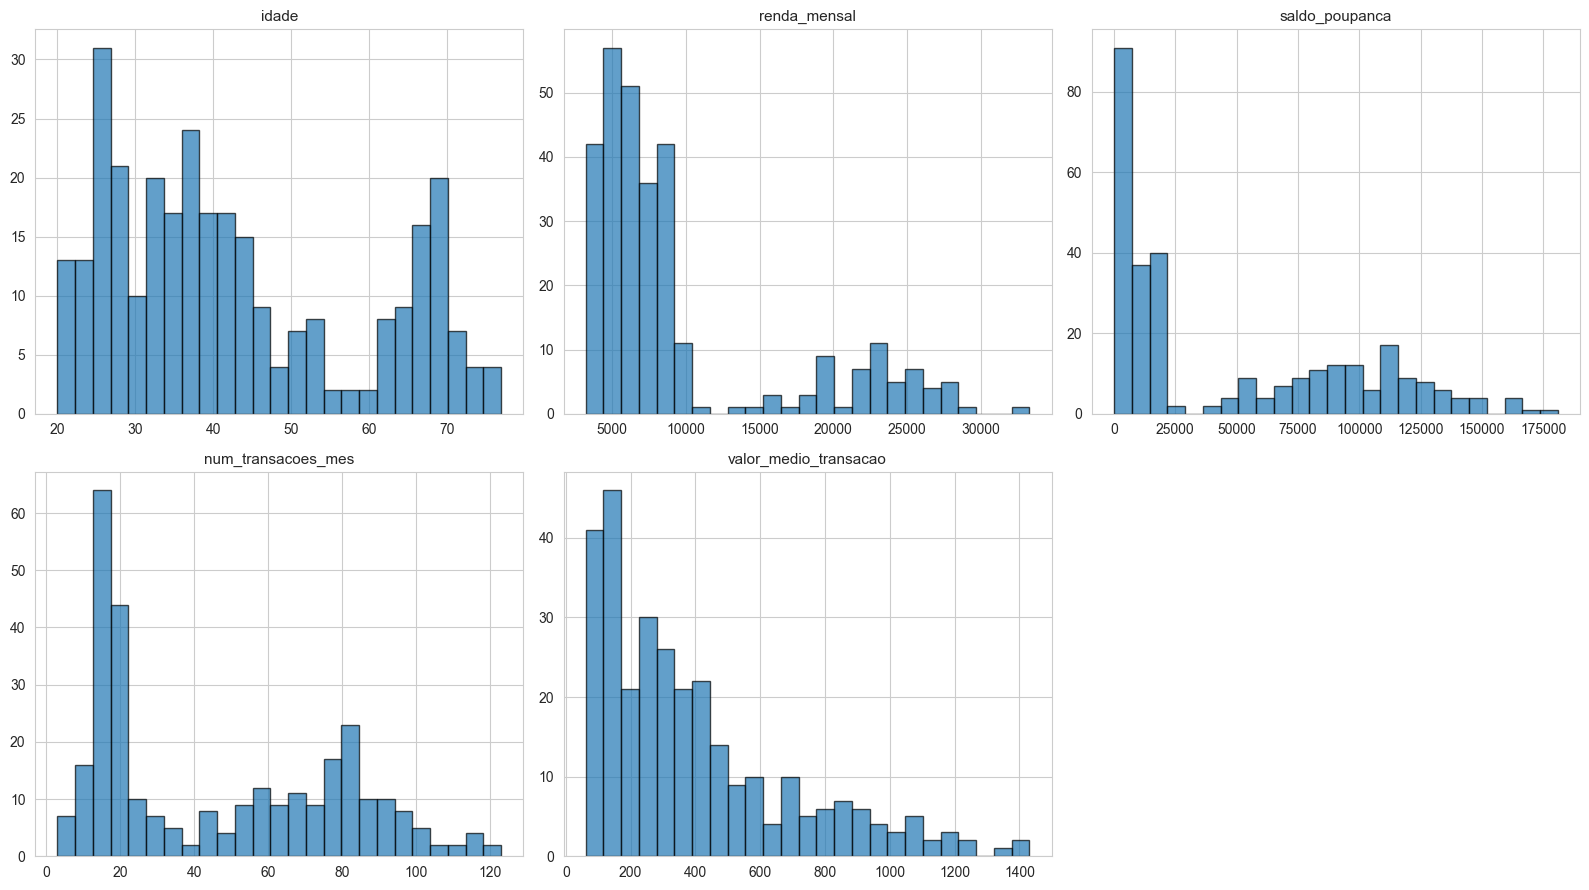

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=25, edgecolor='black', alpha=0.7)
    axes[i].set_title(col, fontsize=11)

# esconder eixo extra (só temos 5 variáveis e 6 subplots)
if len(df.columns) < len(axes):
    axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

Observe que algumas distribuições aparentam ter **vários picos** (multimodais), o que é uma boa indicação da presença de subgrupos nos dados.

### 3.2 Relações entre as Variáveis

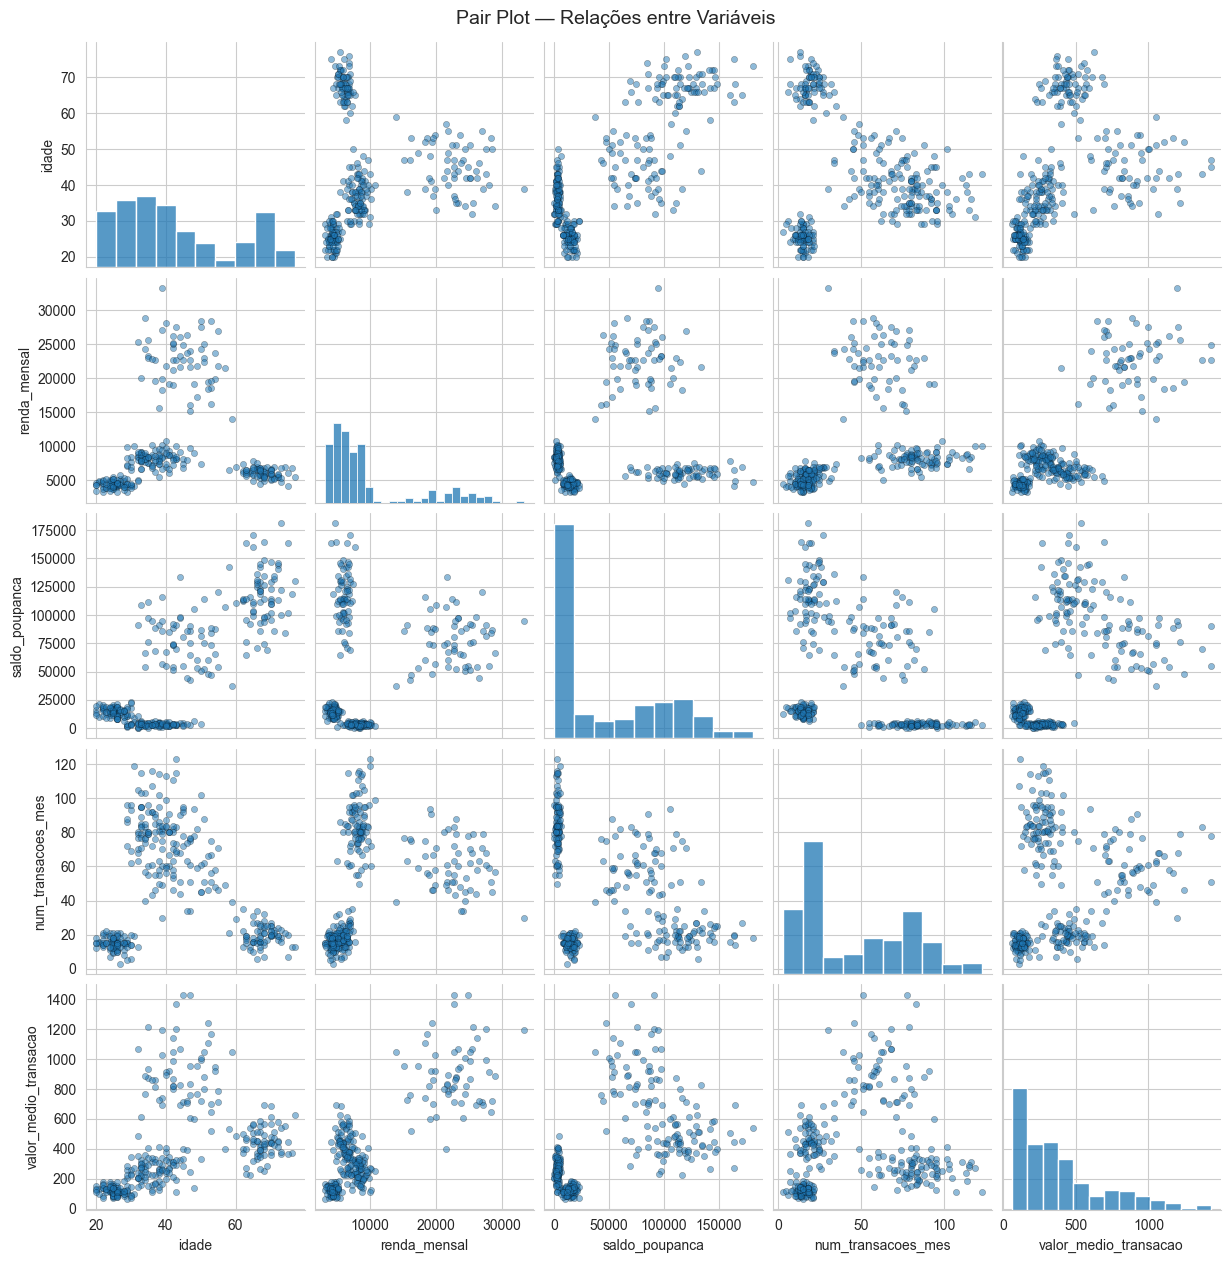

In [5]:
sns.pairplot(df, plot_kws={'alpha': 0.5, 's': 20, 'edgecolor': 'k', 'linewidth': 0.3})
plt.suptitle('Pair Plot — Relações entre Variáveis', y=1.01, fontsize=14)
plt.show()

## 4. Padronização dos Dados

Como vimos no notebook anterior, o K-Means é sensível à escala. As variáveis aqui têm escalas muito diferentes (idade vai até ~80, saldo de poupança chega a 200.000). Padronizar é **essencial**.

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.values)

print(f'Shape dos dados padronizados: {X_scaled.shape}')
print(f'\nMédias após padronização: {X_scaled.mean(axis=0).round(3)}')
print(f'Desvios após padronização: {X_scaled.std(axis=0).round(3)}')

Shape dos dados padronizados: (300, 5)

Médias após padronização: [-0.  0.  0. -0. -0.]
Desvios após padronização: [1. 1. 1. 1. 1.]


## 5. Escolhendo o Número de Clusters

### 5.1 Método do Cotovelo (Elbow Method)

A ideia do método do cotovelo é simples:

1. Treinar o K-Means para vários valores de **K**.
2. Calcular a **inércia** (soma das distâncias quadradas aos centroides) para cada K.
3. Plotar inércia vs K e procurar o ponto onde a curva forma um "**cotovelo**".

A inércia **sempre diminui** quando aumentamos K (com K=N pontos, a inércia é zero). O cotovelo indica o ponto a partir do qual aumentar K traz pouco benefício adicional.

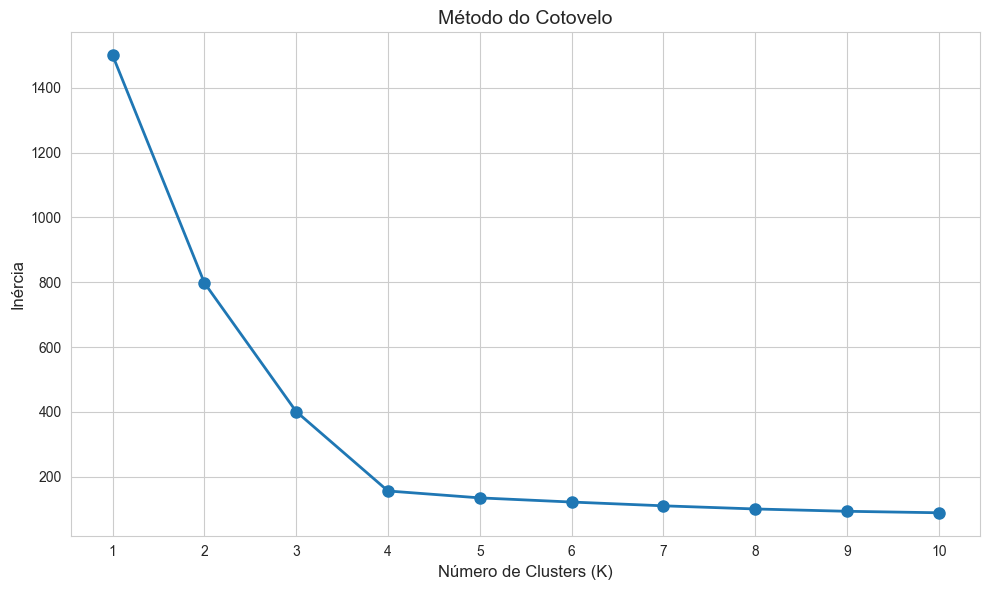

K =  1  ->  Inércia =  1500.00
K =  2  ->  Inércia =   798.13
K =  3  ->  Inércia =   401.47
K =  4  ->  Inércia =   156.53
K =  5  ->  Inércia =   135.22
K =  6  ->  Inércia =   122.40
K =  7  ->  Inércia =   110.73
K =  8  ->  Inércia =   101.04
K =  9  ->  Inércia =    93.89
K = 10  ->  Inércia =    89.31


In [7]:
inercias = []
ks = range(1, 11)

for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_scaled)
    inercias.append(km.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(list(ks), inercias, 'o-', linewidth=2, markersize=8)
plt.xlabel('Número de Clusters (K)', fontsize=12)
plt.ylabel('Inércia', fontsize=12)
plt.title('Método do Cotovelo', fontsize=14)
plt.xticks(list(ks))
plt.tight_layout()
plt.show()

# Mostrar os valores
for k, ine in zip(ks, inercias):
    print(f'K = {k:>2d}  ->  Inércia = {ine:>8.2f}')

### 5.2 Análise do Coeficiente de Silhueta

O método do cotovelo nem sempre é claro — às vezes a curva é suave e o "cotovelo" é difícil de identificar. O **coeficiente de silhueta** é uma alternativa mais objetiva.

Para cada K, calculamos a silhueta média de todas as amostras. **Quanto maior, melhor** a estrutura de clusters.

K =  2  ->  Silhueta = 0.4955
K =  3  ->  Silhueta = 0.6113
K =  4  ->  Silhueta = 0.7069
K =  5  ->  Silhueta = 0.6414
K =  6  ->  Silhueta = 0.5287
K =  7  ->  Silhueta = 0.4271
K =  8  ->  Silhueta = 0.4211
K =  9  ->  Silhueta = 0.4217


K = 10  ->  Silhueta = 0.4207


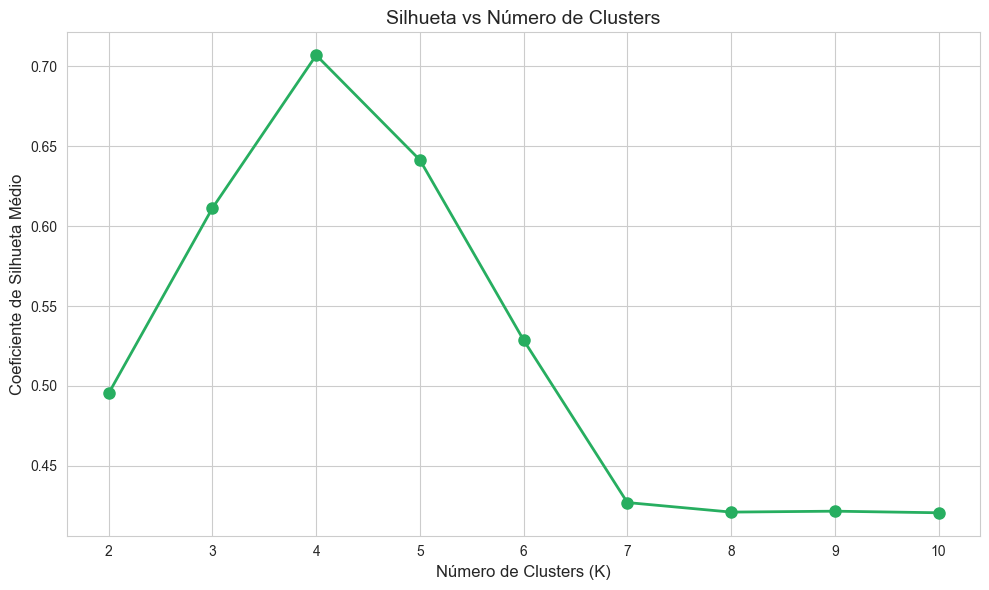

In [8]:
silhuetas = []
ks_sil = range(2, 11)  # silhueta não faz sentido para K=1

for k in ks_sil:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    silhuetas.append(sil)
    print(f'K = {k:>2d}  ->  Silhueta = {sil:.4f}')

plt.figure(figsize=(10, 6))
plt.plot(list(ks_sil), silhuetas, 'o-', linewidth=2, markersize=8, color='#27ae60')
plt.xlabel('Número de Clusters (K)', fontsize=12)
plt.ylabel('Coeficiente de Silhueta Médio', fontsize=12)
plt.title('Silhueta vs Número de Clusters', fontsize=14)
plt.xticks(list(ks_sil))
plt.tight_layout()
plt.show()

O **K com a maior silhueta** é o melhor candidato. Combinando os dois métodos (cotovelo + silhueta), escolhemos o número final de clusters.

In [9]:
K_OTIMO = int(np.argmax(silhuetas) + 2)  # +2 porque ks_sil começa em 2
print(f'K ótimo escolhido (maior silhueta): {K_OTIMO}')

K ótimo escolhido (maior silhueta): 4


## 6. Treinamento Final do Modelo

In [10]:
kmeans = KMeans(n_clusters=K_OTIMO, n_init=10, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df['cluster'] = clusters

print(f'Inércia final: {kmeans.inertia_:.2f}')
print(f'Silhueta final: {silhouette_score(X_scaled, clusters):.4f}')
print(f'\nQuantidade de clientes em cada cluster:')
print(df['cluster'].value_counts().sort_index())

Inércia final: 156.53
Silhueta final: 0.7069

Quantidade de clientes em cada cluster:
cluster
0    90
1    60
2    80
3    70
Name: count, dtype: int64


## 7. Análise dos Clusters (Profiling)

Para entender o perfil de cada cluster, calculamos as **médias** de cada variável por grupo.

In [11]:
perfil = df.groupby('cluster').mean().round(2)
perfil['n_clientes'] = df['cluster'].value_counts().sort_index()
perfil

,idade,renda_mensal,saldo_poupanca,num_transacoes_mes,valor_medio_transacao,n_clientes
cluster,,,,,,
0,36.98,8177.08,3191.56,84.70,263.43,90
1,44.85,22646.04,78068.52,60.73,895.83,60
2,25.44,4402.99,14568.79,14.80,119.05,80
3,67.79,6098.75,117745.86,19.60,443.37,70


### 7.1 Heatmap dos Perfis (valores padronizados)

Para comparar os clusters em uma escala única, usamos as **médias dos valores padronizados**. Valores positivos significam "acima da média geral"; valores negativos, "abaixo da média geral".

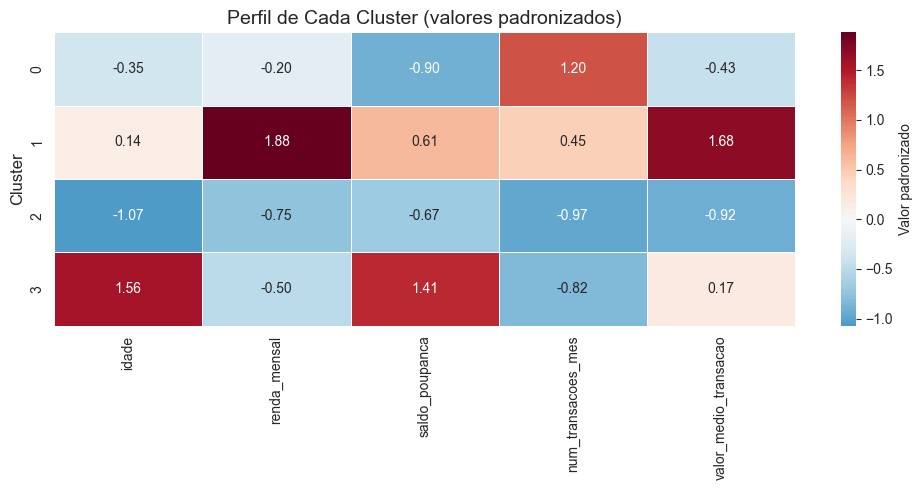

In [12]:
# DataFrame com os dados padronizados + cluster
df_scaled = pd.DataFrame(X_scaled, columns=df.columns[:-1])
df_scaled['cluster'] = clusters

perfil_scaled = df_scaled.groupby('cluster').mean().round(2)

plt.figure(figsize=(10, 5))
sns.heatmap(perfil_scaled, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, cbar_kws={'label': 'Valor padronizado'})
plt.title('Perfil de Cada Cluster (valores padronizados)', fontsize=14)
plt.ylabel('Cluster', fontsize=12)
plt.tight_layout()
plt.show()

### 7.2 Comparando Distribuições por Cluster

Boxplots ajudam a ver como cada variável se distribui em cada cluster.

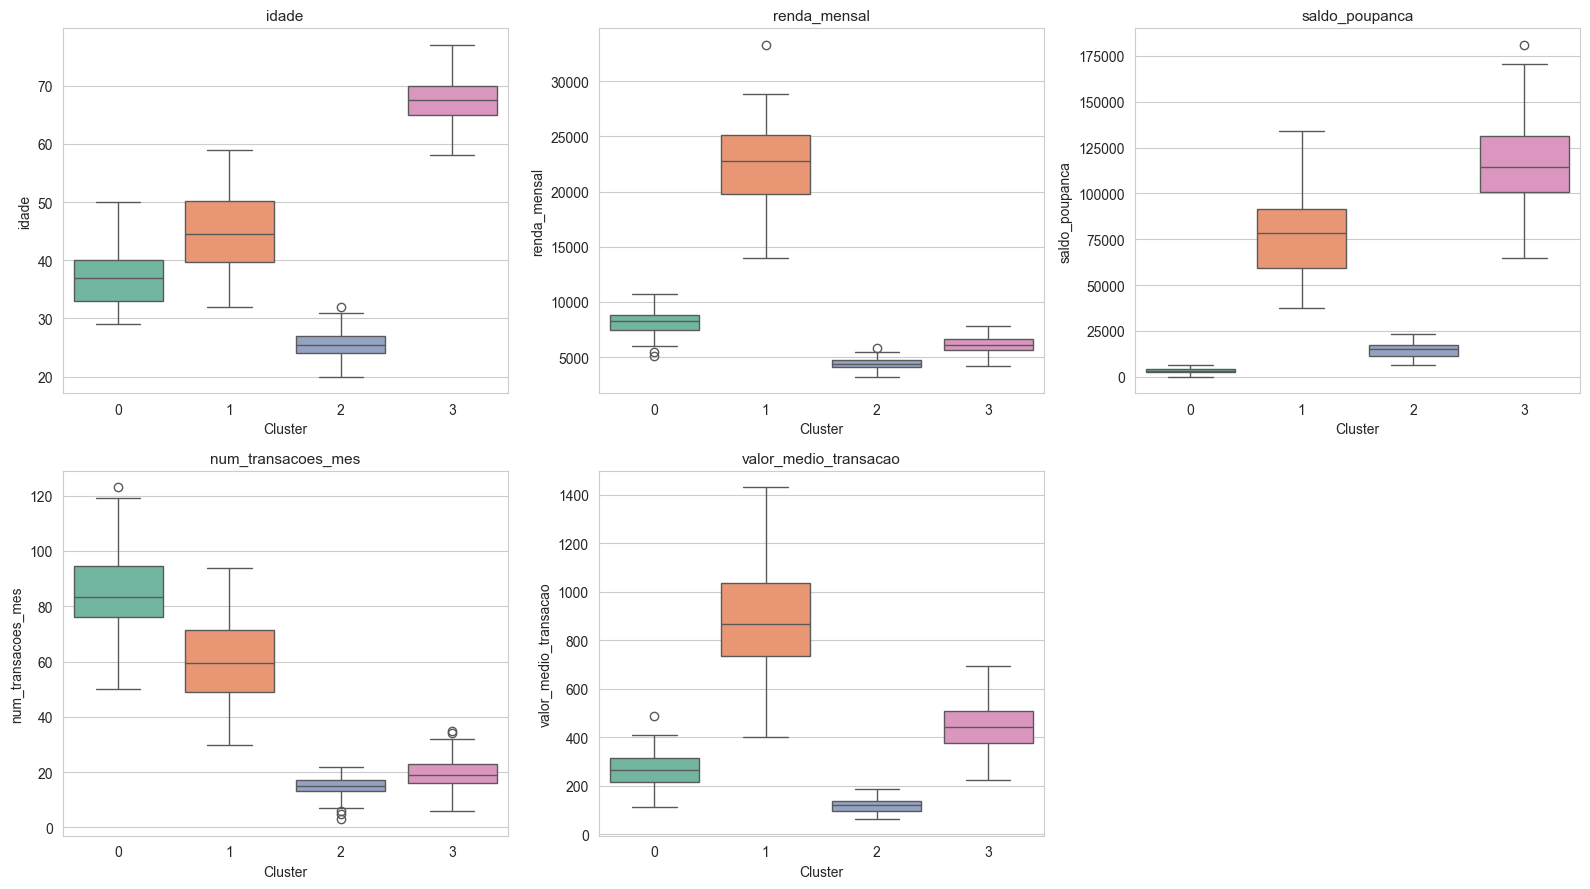

In [13]:
variaveis = df.columns[:-1]  # exclui a coluna 'cluster'
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, var in enumerate(variaveis):
    sns.boxplot(data=df, x='cluster', y=var, ax=axes[i], hue='cluster',
                palette='Set2', legend=False)
    axes[i].set_title(var, fontsize=11)
    axes[i].set_xlabel('Cluster')

if len(variaveis) < len(axes):
    axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

### 7.3 Interpretação dos Clusters

Com base nos gráficos e tabelas acima, podemos atribuir nomes aos clusters. Exemplo de interpretação possível:

- Cluster com **idade alta** e **saldo de poupança altíssimo** → "Aposentados Estáveis"
- Cluster com **renda alta** e **valor médio de transação alto** → "Alta Renda"
- Cluster com **muitas transações** e **baixa poupança** → "Adultos Consumistas"
- Cluster com **idade jovem** e **renda baixa/média** → "Jovens Economizadores"

> A interpretação depende do que você observa nos seus dados — não há regra fixa.

## 8. Visualização dos Clusters com PCA

Como temos 5 dimensões, não conseguimos visualizar diretamente. O **PCA** (Análise de Componentes Principais) é uma técnica que **reduz a dimensionalidade** mantendo o máximo de variabilidade dos dados.

Vamos projetar os dados em 2 dimensões só para a visualização.

In [14]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

variancia_explicada = pca.explained_variance_ratio_
print(f'Variância explicada por PC1: {variancia_explicada[0]:.2%}')
print(f'Variância explicada por PC2: {variancia_explicada[1]:.2%}')
print(f'Total acumulado:             {variancia_explicada.sum():.2%}')

Variância explicada por PC1: 49.92%
Variância explicada por PC2: 33.45%
Total acumulado:             83.36%


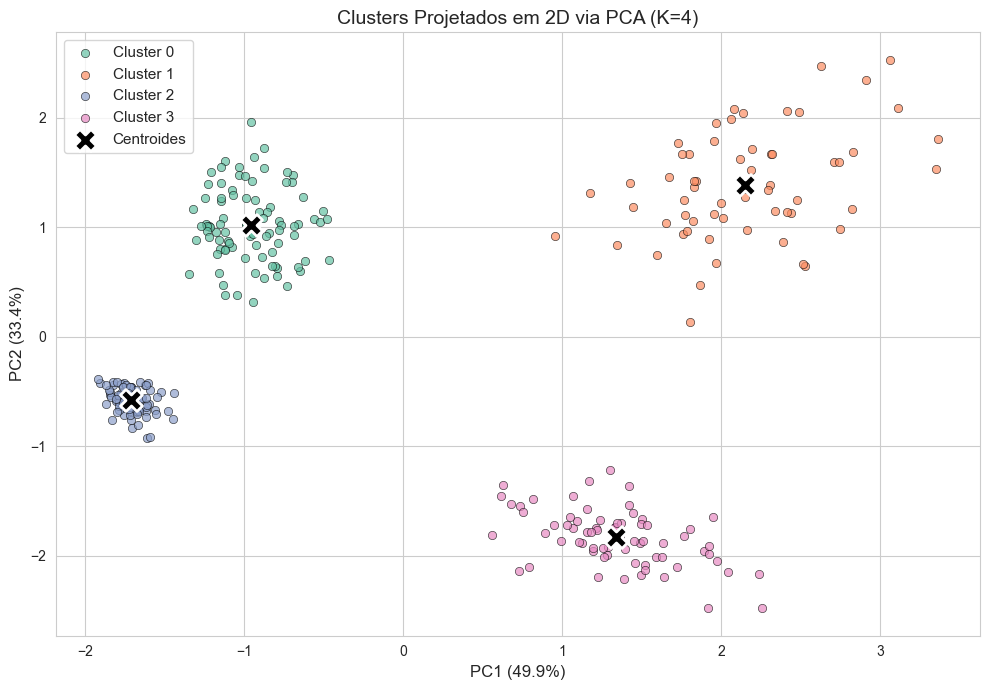

In [15]:
plt.figure(figsize=(10, 7))

cores = sns.color_palette('Set2', n_colors=K_OTIMO)
for cluster_id in range(K_OTIMO):
    mask = clusters == cluster_id
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=[cores[cluster_id]], alpha=0.7,
                edgecolors='k', linewidths=0.5,
                label=f'Cluster {cluster_id}')

# Centroides projetados no espaço PCA
centroides_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroides_pca[:, 0], centroides_pca[:, 1],
            c='black', marker='X', s=250, edgecolors='white', linewidths=2,
            label='Centroides')

plt.xlabel(f'PC1 ({variancia_explicada[0]:.1%})', fontsize=12)
plt.ylabel(f'PC2 ({variancia_explicada[1]:.1%})', fontsize=12)
plt.title(f'Clusters Projetados em 2D via PCA (K={K_OTIMO})', fontsize=14)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 9. Análise de Silhueta por Amostra

Além da silhueta média, podemos olhar a silhueta **de cada amostra individualmente**. Isso ajuda a identificar:

- Clusters com amostras de silhueta muito baixa (mal posicionadas).
- Clusters com tamanhos muito desbalanceados.
- A presença de amostras com silhueta **negativa** (provavelmente atribuídas ao cluster errado).

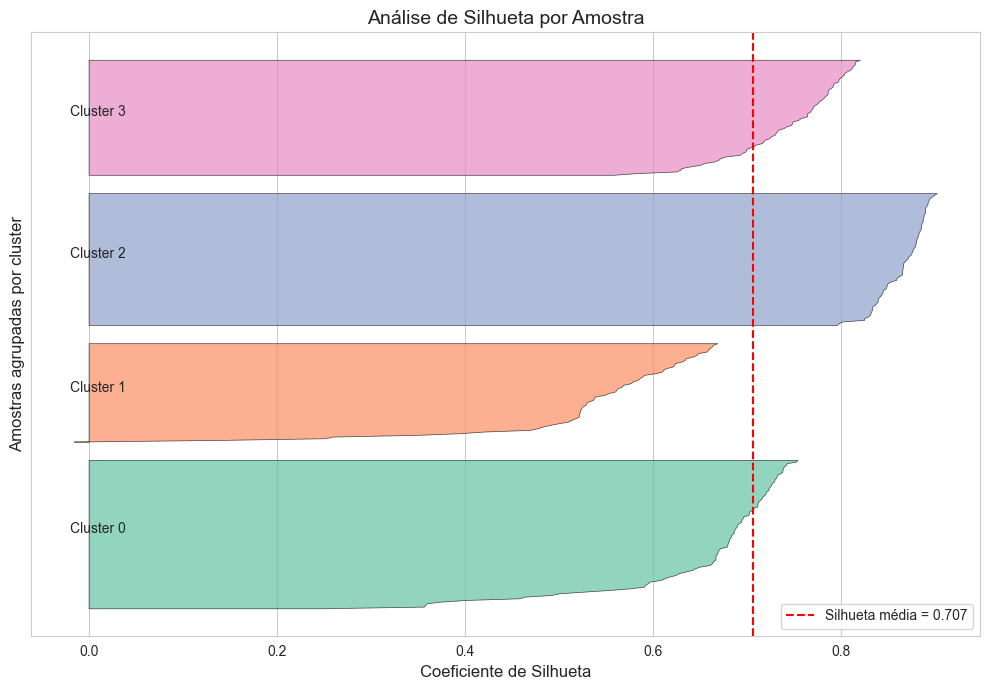

In [16]:
sil_amostras = silhouette_samples(X_scaled, clusters)
sil_media = silhouette_score(X_scaled, clusters)

fig, ax = plt.subplots(figsize=(10, 7))
y_lower = 10

for i in range(K_OTIMO):
    sil_cluster = sil_amostras[clusters == i]
    sil_cluster.sort()
    tamanho = sil_cluster.shape[0]
    y_upper = y_lower + tamanho

    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, sil_cluster,
                     facecolor=cores[i], alpha=0.7, edgecolor='black', linewidth=0.5)
    ax.text(-0.02, y_lower + 0.5 * tamanho, f'Cluster {i}', fontsize=10)
    y_lower = y_upper + 10

ax.axvline(x=sil_media, color='red', linestyle='--', label=f'Silhueta média = {sil_media:.3f}')
ax.set_xlabel('Coeficiente de Silhueta', fontsize=12)
ax.set_ylabel('Amostras agrupadas por cluster', fontsize=12)
ax.set_title('Análise de Silhueta por Amostra', fontsize=14)
ax.set_yticks([])
ax.legend()
plt.tight_layout()
plt.show()

## 10. Resumo

Neste notebook vimos:

1. Para escolher o **número de clusters** quando ele não é conhecido, use o **Método do Cotovelo** e o **Coeficiente de Silhueta** em conjunto.
2. **Padronizar os dados** é essencial em datasets com várias escalas.
3. Para **interpretar** os clusters, calcule médias por grupo, use heatmaps de valores padronizados e boxplots.
4. **PCA** é uma forma prática de visualizar clusters em alta dimensão (mas é apenas uma projeção — pode haver sobreposições no espaço 2D que não existem no espaço original).
5. A **silhueta por amostra** ajuda a diagnosticar problemas pontuais nos clusters.